## The Nobel Prize

***“Through knowledge, integrity and excellence, through creativity and inspiration, the laureates offer hope. They remind us that it is possible, through different paths, to address and come to terms with the many global challenges we face today.”***
<br><br>
Professor Astrid Söderbergh Widding in her opening speech at the award ceremony 2025
</quote>
<br><br>
The Nobel prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](../images/Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, we'll explore and answer several questions related to this prize-winning data.

In [1]:
# Loading in required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# read the data file, check columns and inspect 1st few records
df_nobel = pd.read_csv('../data/nobel.csv', parse_dates = ['birth_date', 'death_date'])
print(f"Shape of df_nobel: {df_nobel.shape}\n")
print(df_nobel.columns, '\n')
print(df_nobel.info(), '\n')
df_nobel.tail()

Shape of df_nobel: (1000, 18)

Index(['year', 'category', 'prize', 'motivation', 'prize_share', 'laureate_id',
       'laureate_type', 'full_name', 'birth_date', 'birth_city',
       'birth_country', 'sex', 'organization_name', 'organization_city',
       'organization_country', 'death_date', 'death_city', 'death_country'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   year                  1000 non-null   int64         
 1   category              1000 non-null   object        
 2   prize                 1000 non-null   object        
 3   motivation            912 non-null    object        
 4   prize_share           1000 non-null   object        
 5   laureate_id           1000 non-null   int64         
 6   laureate_type         1000 non-null   object        
 7   full_name        

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
995,2023,Chemistry,The Nobel Prize in Chemistry 2023,"""for the discovery and synthesis of quantum dots""",1/3,1030,Individual,Louis Brus,1943-00-00,"Cleveland, OH",United States of America,Male,Columbia University,"New York, NY",United States of America,NaT,NaN,NaN
996,2023,Chemistry,The Nobel Prize in Chemistry 2023,"""for the discovery and synthesis of quantum dots""",1/3,1031,Individual,Aleksey Yekimov,1945-00-00,NaN,USSR (now Russia),Male,Nanocrystals Technology Inc.,"New York, NY",United States of America,NaT,NaN,NaN
997,2023,Literature,The Nobel Prize in Literature 2023,"""for his innovative plays and prose which give...",1/1,1032,Individual,Jon Fosse,1959-09-29,Haugesund,Norway,Male,NaN,NaN,NaN,NaT,NaN,NaN
998,2023,Peace,The Nobel Peace Prize 2023,"""for her fight against the oppression of women...",1/1,1033,Individual,Narges Mohammadi,1972-04-21,Zanjan,Iran,Female,NaN,NaN,NaN,NaT,NaN,NaN
999,2023,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having advanced our understanding of wome...",1/1,1034,Individual,Claudia Goldin,1946-00-00,"New York, NY",United States of America,Female,Harvard University,"Cambridge, MA",United States of America,NaT,NaN,NaN


## `birth_date` column was not parsed to datetime as expected

We'll deal with this later in the analysis.

## What is the most commonly awarded gender?

No big suprises here, but what is interesting is the magnitude of the difference.

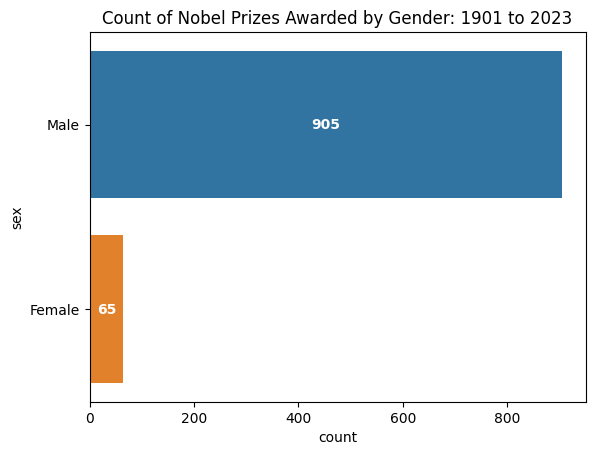

The gender with the most Nobel Prizes is : Male with 905 prize count


In [2]:
# need to rename the count series before resetting index to avoid name collision
df_sex = df_nobel.groupby(by='sex')['sex'].count().rename('count').reset_index()
df_sex = df_sex.sort_values(by='sex', ascending=False)
ax = sns.barplot(data=df_sex, x='count', y='sex', hue='sex')
# add the counts to the bars
for cont in ax.containers:
    ax.bar_label(cont, label_type='center', color='white', fontweight='bold')
# add title
ax.set_title("Count of Nobel Prizes Awarded by Gender: 1901 to 2023")
plt.show()

top_gender = df_sex.iloc[0, 0]  # top gender is 1st tuple in list
print(f"The gender with the most Nobel Prizes is : {top_gender} with {df_sex.iloc[0, 1]} prize count")

## What are the most commonly awarded birth countries?

What makes this a little ticky is the fact that country borders and designations have shifted since 1901. The listed birth countries were written out and a mapping was created in the file `country_mapping.csv`. This file was then used to consolidate the number of `birth_country` listings.

In [3]:
pd.set_option('display.max_rows', None)
country_counts = df_nobel['birth_country'].value_counts().sort_index()
country_counts.to_csv('country_counts.csv')  # write out countries to create mapping off-line
print(country_counts[:10])                   # can see the issue in the first 10 listings

birth_country
Argentina                                    4
Australia                                   10
Austria                                     16
Austria-Hungary (Austria)                    1
Austria-Hungary (Bosnia and Herzegovina)     1
Austria-Hungary (Croatia)                    1
Austria-Hungary (Czech Republic)             4
Austria-Hungary (Hungary)                    3
Austria-Hungary (Poland)                     1
Austria-Hungary (Slovenia)                   1
Name: count, dtype: int64


In [4]:
# read in the list and create a dict to make the mapping easier
df_country_mapping = pd.read_csv('country_mapping.csv')
country_mapping_dict = dict(zip(df_country_mapping['original_birth_country'], df_country_mapping['mapped_country']))
# update the countries to the new mapped values
df_nobel['contemporary_country'] = df_nobel['birth_country'].map(country_mapping_dict)
# check a few of the changed rows
df_nobel.loc[[2,5,6,7,15,19], ['year', 'category', 'full_name', 'birth_country', 'contemporary_country']]

,year,category,full_name,birth_country,contemporary_country
2,1901,Medicine,Emil Adolf von Behring,Prussia (Poland),Poland
5,1901,Physics,Wilhelm Conrad Röntgen,Prussia (Germany),Germany
6,1902,Chemistry,Hermann Emil Fischer,Prussia (Germany),Germany
7,1902,Literature,Christian Matthias Theodor Mommsen,Schleswig (Germany),Germany
15,1903,Medicine,Niels Ryberg Finsen,Faroe Islands (Denmark),Denmark
19,1903,Physics,"Marie Curie, née Sklodowska",Russian Empire (Poland),Poland


In [5]:
# check the country counts before and after consolidation
print(f"There were {country_counts.shape[0]} birth countries listings BEFORE consolidation.")
print(f"\nThere were {df_nobel['contemporary_country'].nunique()} birth countries listings AFTER consolidation.")

There were 129 birth countries listings BEFORE consolidation.

There were 84 birth countries listings AFTER consolidation.


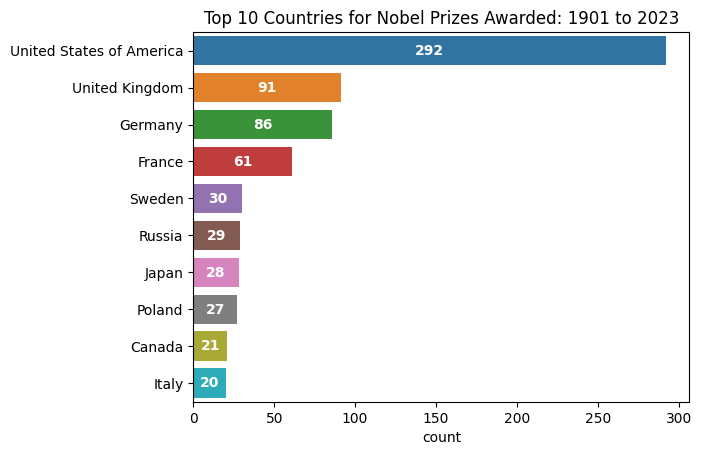

The country with the most Nobel Prizes is : United States of America with 292


In [6]:
# visualize the top 10
df_top_10_countries_awarded = pd.DataFrame(df_nobel['contemporary_country'].value_counts()[:10]).reset_index()
ax = sns.barplot(data=df_top_10_countries_awarded, x='count', y='contemporary_country',
                 hue='contemporary_country')
# add the counts to the bars
for cont in ax.containers:
    ax.bar_label(cont, label_type='center', color='white', fontweight='bold')
# add title
ax.set_title("Top 10 Countries for Nobel Prizes Awarded: 1901 to 2023")
# don't need ylabel
ax.set_ylabel("")
plt.show()

top_country = df_top_10_countries_awarded.iloc[0, 0]
top_country_count = df_top_10_countries_awarded.iloc[0, 1]
print(f"The country with the most Nobel Prizes is : {top_country} with {top_country_count}")

## Which decade had the highest ratio of US-born Nobel Prize winners to total winners in all categories?

+ How do the top 4 countries look in terms of number of awards over time?
+ How does the US proportion of wards look over time?

In [7]:
# we'll use sex column in future sections
df_over_time = df_nobel.loc[:, ["year", "contemporary_country", "category", "sex"]]
df_over_time = df_over_time.sort_values(by=["year", "contemporary_country"])
# create decade column
df_over_time['decade'] = df_over_time["year"].astype(str).str[:3] + "0"
# shorten the country column name
df_over_time = df_over_time.rename(columns={"contemporary_country": "country"})
df_over_time['top_country'] = df_over_time['country'].apply(lambda c: c if c in ('United States of America',
                                                                                 'United Kingdom',
                                                                                 'Germany',
                                                                                 'France') else 'Other')

df_over_time.sort_values(by=['year', 'category'], inplace=True)
print(f"Shape of df_over_time: {df_over_time.shape}\n")
# check out new is_USA column
df_over_time.loc[df_over_time['country'] == "United States of America", :].head()

Shape of df_over_time: (1000, 6)



,year,country,category,sex,decade,top_country
35,1906,United States of America,Peace,Male,1900,United States of America
72,1912,United States of America,Peace,Male,1910,United States of America
79,1914,United States of America,Chemistry,Male,1910,United States of America
95,1919,United States of America,Peace,Male,1910,United States of America
117,1923,United States of America,Physics,Male,1920,United States of America


In [8]:
df_top_countries = pd.crosstab(df_over_time['decade'], df_over_time['top_country']).reset_index()
df_top_countries.columns.name = None
# reorder the columns
df_top_countries = df_top_countries[['decade', 'United States of America',
                                     'United Kingdom', 'Germany', 'France', 'Other']]
df_top_countries.set_index('decade', inplace=True)
df_top_countries.head()

,United States of America,United Kingdom,Germany,France,Other
decade,,,,,
1900,1,3,8,9,36
1910,3,2,7,6,22
1920,4,7,11,8,24
1930,14,10,8,3,21
1940,13,3,3,1,23


In [9]:
# add total awards
df_top_countries['total_award'] = df_top_countries['United States of America'] + \
                                  df_top_countries['United Kingdom'] + \
                                  df_top_countries['Germany'] + \
                                  df_top_countries['France'] + \
                                  df_top_countries['Other']
# calc US proportion of awards
df_top_countries['USA_prop'] = df_top_countries['United States of America'] / df_top_countries['total_award']
df_top_countries.head()

,United States of America,United Kingdom,Germany,France,Other,total_award,USA_prop
decade,,,,,,,
1900,1,3,8,9,36,57,0.017544
1910,3,2,7,6,22,40,0.075000
1920,4,7,11,8,24,54,0.074074
1930,14,10,8,3,21,56,0.250000
1940,13,3,3,1,23,43,0.302326


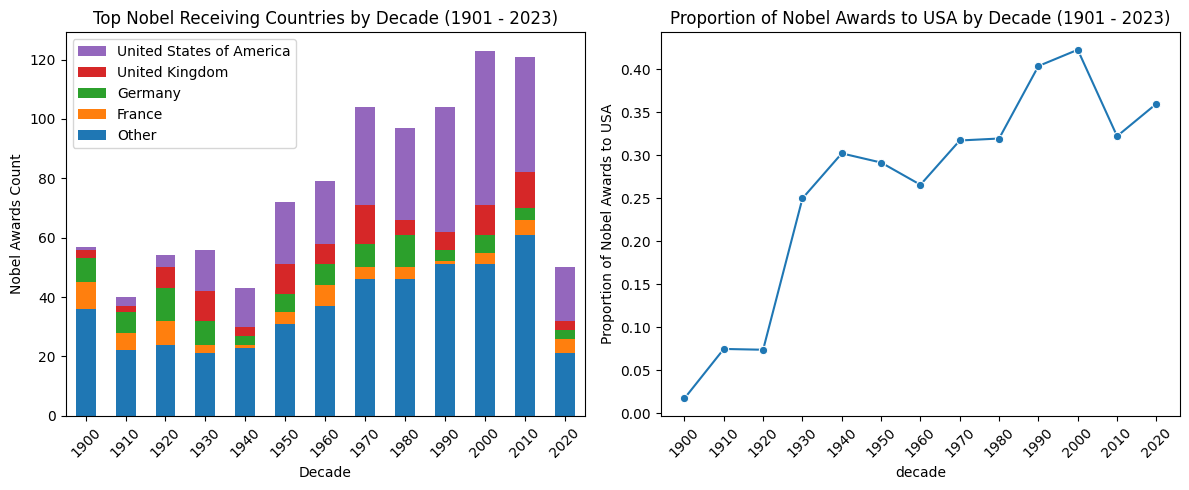

In [10]:
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
# create df for left plot
# df_left_plot = df_top_countries[['United States of America', 'United Kingdom', 'Germany', 'France', 'Other']]
df_left_plot = df_top_countries[['Other', 'France', 'Germany', 'United Kingdom', 'United States of America']]
df_left_plot.plot(kind='bar', stacked=True,
                  title="Top Nobel Receiving Countries by Decade (1901 - 2023)",
                  xlabel="Decade", ylabel="Nobel Awards Count", ax=ax1[0])
# create df for right plot
df_right_plot = df_top_countries[["USA_prop"]]
# USA proportion over the decades
g = sns.lineplot(data=df_right_plot, x="decade", y="USA_prop", marker='o', ax=ax1[1])
g.set_ylabel("Proportion of Nobel Awards to USA")
g.set_title("Proportion of Nobel Awards to USA by Decade (1901 - 2023)")
# rotate the x-axis ticks
ax1[0].tick_params(axis='x', labelrotation=45)
ax1[1].tick_params(axis='x', labelrotation=45)
# change order of legend to match the bars - Get the handles and labels
handles, labels = ax1[0].get_legend_handles_labels()
ax1[0].legend(reversed(handles), reversed(labels), title='')

plt.tight_layout()
plt.show()

In [11]:
df_left_plot.head()

,Other,France,Germany,United Kingdom,United States of America
decade,,,,,
1900,36,9,8,3,1
1910,22,6,7,2,3
1920,24,8,11,7,4
1930,21,3,8,10,14
1940,23,1,3,3,13


In [12]:
# just need to sort to confirm what we see visually
best_usa_decade = df_top_countries.sort_values(by='USA_prop', ascending=False).reset_index().loc[0, 'decade']
best_usa_prop = df_top_countries.sort_values(by='USA_prop', ascending=False).reset_index().loc[0, 'USA_prop']
print(f"Best decade for USA Nobels was {best_usa_decade} with {round(best_usa_prop * 100)}% of the prizes awarded that year")

Best decade for USA Nobels was 2000 with 42% of the prizes awarded that year


## What does the overall proportion of female Nobel laureates look like over time?

In [13]:
# Create dataframe with count of female winners in each each decade (over all categories)
df_sex_dec = df_nobel.loc[:, ["year", "sex"]]
df_sex_dec['decade'] = df_sex_dec["year"].astype(str).str[:3] + "0"
df_sex_counts = df_sex_dec.pivot_table(index='decade', columns='sex', values='sex', aggfunc='count', fill_value=0).reset_index()
df_sex_counts.columns.name = None
df_sex_counts['total_awards'] = df_sex_counts['Female'] + df_sex_counts['Male']
df_sex_counts['Female_prop'] = df_sex_counts['Female'] / df_sex_counts['total_awards']
df_sex_counts['Male_prop'] = df_sex_counts['Male'] / df_sex_counts['total_awards']
df_sex_counts.head()

,decade,Female,Male,total_awards,Female_prop,Male_prop
0,1900,3,53,56,0.053571,0.946429
1,1910,1,37,38,0.026316,0.973684
2,1920,2,52,54,0.037037,0.962963
3,1930,3,52,55,0.054545,0.945455
4,1940,3,37,40,0.075000,0.925000


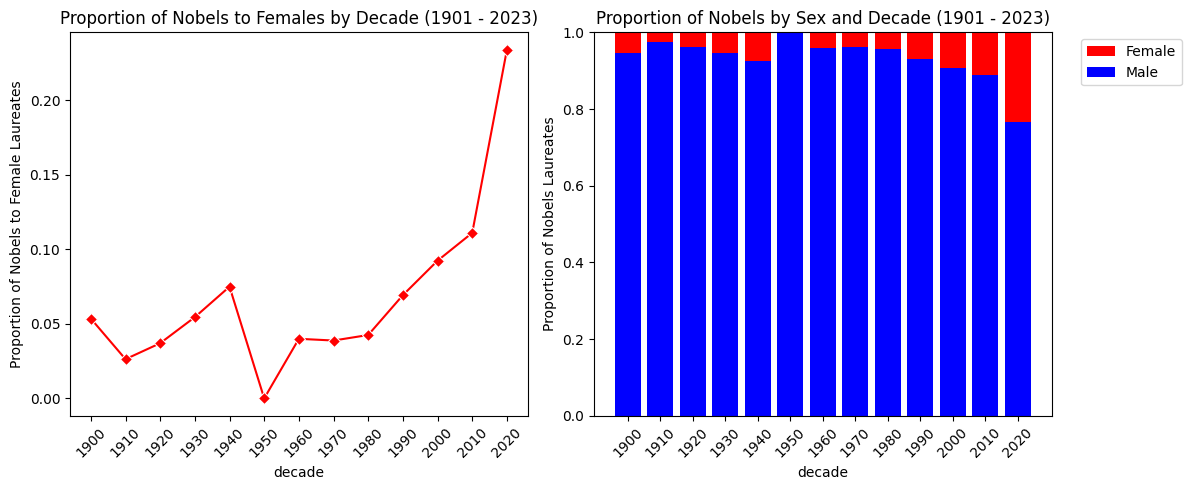

In [14]:
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
# create df for left plot - Female proportion over the decades
sns.lineplot(data=df_sex_counts, x="decade", y="Female_prop", marker='D', c='red', ax=ax2[0])
ax2[0].set_ylabel("Proportion of Nobels to Female Laureates")
ax2[0].set_title("Proportion of Nobels to Females by Decade (1901 - 2023)")
ax2[0].tick_params(axis='x', labelrotation=45)
# create right bar: stacked bar
ax2[1].bar(x=df_sex_counts['decade'], height=df_sex_counts['Male_prop'], label='Male', color='blue')
ax2[1].bar(x=df_sex_counts['decade'], height=df_sex_counts['Female_prop'], bottom=df_sex_counts['Male_prop'], label='Female', color='red')
ax2[1].set_ylabel("Proportion of Nobels Laureates")
ax2[1].set_xlabel("decade")
ax2[1].set_title("Proportion of Nobels by Sex and Decade (1901 - 2023)")
ax2[1].tick_params(axis='x', labelrotation=45)

# change order of legend to match the bars - get the handles and labels
handles, labels = ax2[1].get_legend_handles_labels()
# need combine the change of order and position of the legend because...
# ax.legend() isn't an "update" command; it's a "create/replace" command. 
ax2[1].legend(# change the order of the legend
              reversed(handles),
              reversed(labels),
              title='',
              # move the legend outside the right plot
              bbox_to_anchor=(1.05, 1),
              loc='upper left',
              fontsize=10)

plt.tight_layout()
plt.show()

## Which decade and Nobel Prize category combination had the highest proportion of female laureates?

We can see from the plots in the previous cell, that since the 1980's, we see a positive trend of more women receiving Nobel prizes. Now let's take a look at what categories women laureates are winning. A bit of wrangling is required here...

1. Create dataframe with count of female winners in each category for each decade
2. Repeat 1. for the male winners
3. Calculated the proportion of female winners in each category for each decade


In [15]:
df_over_time.head()

,year,country,category,sex,decade,top_country
0,1901,Netherlands,Chemistry,Male,1900,Other
1,1901,France,Literature,Male,1900,France
2,1901,Poland,Medicine,Male,1900,Other
4,1901,France,Peace,Male,1900,France
3,1901,Switzerland,Peace,Male,1900,Other


In [16]:
df_fem_cat = df_over_time.loc[df_over_time['sex'] == 'Female', ['decade', 'category']]
df_fem_cat = pd.DataFrame(df_fem_cat.groupby(['decade', 'category'])['category'].count())
df_fem_cat = df_fem_cat.rename(columns = {'category': 'count'})  # must do this before reset_index() to avoid category name collision
df_fem_cat = df_fem_cat.reset_index()
df_fem_cat = df_fem_cat.pivot(index='decade', columns='category', values='count').fillna(0)

In [17]:
df_fem_cat.columns.name = None
df_fem_cat['total_women'] = df_fem_cat['Chemistry'] + df_fem_cat['Economics'] + df_fem_cat['Literature'] + \
                            df_fem_cat['Medicine'] + df_fem_cat['Peace'] + df_fem_cat['Physics']
df_fem_cat

,Chemistry,Economics,Literature,Medicine,Peace,Physics,total_women
decade,,,,,,,
1900,0.0,0.0,1.0,0.0,1.0,1.0,3.0
1910,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1920,0.0,0.0,2.0,0.0,0.0,0.0,2.0
1930,1.0,0.0,1.0,0.0,1.0,0.0,3.0
1940,0.0,0.0,1.0,1.0,1.0,0.0,3.0
1960,1.0,0.0,1.0,0.0,0.0,1.0,3.0
1970,0.0,0.0,0.0,1.0,3.0,0.0,4.0
1980,0.0,0.0,0.0,3.0,1.0,0.0,4.0
1990,0.0,0.0,3.0,1.0,3.0,0.0,7.0


In [18]:
# rename cols so we can id them when we join
df_fem_cat = df_fem_cat.rename(columns={'Chemistry': 'Chemistry_women', 'Economics': 'Economics_women',
                                        'Literature': 'Literature_women', 'Medicine': 'Medicine_women',
                                        'Peace': 'Peace_women', 'Physics': 'Physics_women'})
df_fem_cat.tail()

,Chemistry_women,Economics_women,Literature_women,Medicine_women,Peace_women,Physics_women,total_women
decade,,,,,,,
1980,0.0,0.0,0.0,3.0,1.0,0.0,4.0
1990,0.0,0.0,3.0,1.0,3.0,0.0,7.0
2000,1.0,1.0,3.0,4.0,2.0,0.0,11.0
2010,1.0,1.0,3.0,2.0,5.0,1.0,13.0
2020,3.0,1.0,2.0,1.0,2.0,2.0,11.0


In [19]:
df_men_cat = df_over_time.loc[df_over_time['sex'] == 'Male', ['decade', 'category']]
df_men_cat = pd.DataFrame(df_men_cat.groupby(['decade', 'category'])['category'].count())
df_men_cat = df_men_cat.rename(columns = {'category': 'count'})
df_men_cat = df_men_cat.reset_index()
df_men_cat = df_men_cat.pivot(index='decade', columns='category', values='count').fillna(0)
df_men_cat.columns.name = None
df_men_cat['total_men'] = df_men_cat['Chemistry'] + df_men_cat['Economics'] + df_men_cat['Literature'] + \
                          df_men_cat['Medicine'] + df_men_cat['Peace'] + df_men_cat['Physics']
# rename cols so we can id them when we join
df_men_cat = df_men_cat.rename(columns={'Chemistry': 'Chemistry_men', 'Economics': 'Economics_men',
                                        'Literature': 'Literature_men', 'Medicine': 'Medicine_men',
                                        'Peace': 'Peace_men', 'Physics': 'Physics_men'})
df_men_cat.tail()

,Chemistry_men,Economics_men,Literature_men,Medicine_men,Peace_men,Physics_men,total_men
decade,,,,,,,
1980,21.0,10.0,10.0,20.0,7.0,22.0,90.0
1990,18.0,17.0,7.0,19.0,11.0,22.0,94.0
2000,24.0,19.0,7.0,22.0,8.0,28.0,108.0
2010,26.0,19.0,7.0,22.0,5.0,25.0,104.0
2020,7.0,8.0,2.0,7.0,2.0,10.0,36.0


In [20]:
# join the women and men, then compute the women prop's by cat
df_both_sex = df_fem_cat.merge(df_men_cat, left_index=True, right_index=True, how='inner')
df_both_sex

,Chemistry_women,Economics_women,Literature_women,Medicine_women,Peace_women,Physics_women,total_women,Chemistry_men,Economics_men,Literature_men,Medicine_men,Peace_men,Physics_men,total_men
decade,,,,,,,,,,,,,,
1900,0.0,0.0,1.0,0.0,1.0,1.0,3.0,9.0,0.0,9.0,11.0,12.0,12.0,53.0
1910,1.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,0.0,9.0,6.0,5.0,10.0,37.0
1920,0.0,0.0,2.0,0.0,0.0,0.0,2.0,10.0,0.0,8.0,11.0,11.0,12.0,52.0
1930,1.0,0.0,1.0,0.0,1.0,0.0,3.0,12.0,0.0,8.0,14.0,7.0,11.0,52.0
1940,0.0,0.0,1.0,1.0,1.0,0.0,3.0,9.0,0.0,5.0,13.0,3.0,7.0,37.0
1960,1.0,0.0,1.0,0.0,0.0,1.0,3.0,14.0,2.0,10.0,25.0,5.0,16.0,72.0
1970,0.0,0.0,0.0,1.0,3.0,0.0,4.0,15.0,15.0,11.0,24.0,9.0,25.0,99.0
1980,0.0,0.0,0.0,3.0,1.0,0.0,4.0,21.0,10.0,10.0,20.0,7.0,22.0,90.0
1990,0.0,0.0,3.0,1.0,3.0,0.0,7.0,18.0,17.0,7.0,19.0,11.0,22.0,94.0


In [21]:
df_both_sex['Chemistry'] = df_both_sex['Chemistry_women'] / (df_both_sex['Chemistry_women'] + df_both_sex['Chemistry_men'])
df_both_sex['Economics'] = df_both_sex['Economics_women'] / (df_both_sex['Economics_women'] + df_both_sex['Economics_men'])
df_both_sex['Literature'] = df_both_sex['Literature_women'] / (df_both_sex['Literature_women'] + df_both_sex['Literature_men'])
df_both_sex['Medicine'] = df_both_sex['Medicine_women'] / (df_both_sex['Medicine_women'] + df_both_sex['Medicine_men'])
df_both_sex['Peace'] = df_both_sex['Peace_women'] / (df_both_sex['Peace_women'] + df_both_sex['Peace_men'])
df_both_sex['Physics'] = df_both_sex['Physics_women'] / (df_both_sex['Physics_women'] + df_both_sex['Physics_men'])
df_both_sex

,Chemistry_women,Economics_women,Literature_women,Medicine_women,Peace_women,Physics_women,total_women,Chemistry_men,Economics_men,Literature_men,Medicine_men,Peace_men,Physics_men,total_men,Chemistry,Economics,Literature,Medicine,Peace,Physics
decade,,,,,,,,,,,,,,,,,,,,
1900,0.0,0.0,1.0,0.0,1.0,1.0,3.0,9.0,0.0,9.0,11.0,12.0,12.0,53.0,0.000000,NaN,0.100000,0.000000,0.076923,0.076923
1910,1.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,0.0,9.0,6.0,5.0,10.0,37.0,0.125000,NaN,0.000000,0.000000,0.000000,0.000000
1920,0.0,0.0,2.0,0.0,0.0,0.0,2.0,10.0,0.0,8.0,11.0,11.0,12.0,52.0,0.000000,NaN,0.200000,0.000000,0.000000,0.000000
1930,1.0,0.0,1.0,0.0,1.0,0.0,3.0,12.0,0.0,8.0,14.0,7.0,11.0,52.0,0.076923,NaN,0.111111,0.000000,0.125000,0.000000
1940,0.0,0.0,1.0,1.0,1.0,0.0,3.0,9.0,0.0,5.0,13.0,3.0,7.0,37.0,0.000000,NaN,0.166667,0.071429,0.250000,0.000000
1960,1.0,0.0,1.0,0.0,0.0,1.0,3.0,14.0,2.0,10.0,25.0,5.0,16.0,72.0,0.066667,0.000000,0.090909,0.000000,0.000000,0.058824
1970,0.0,0.0,0.0,1.0,3.0,0.0,4.0,15.0,15.0,11.0,24.0,9.0,25.0,99.0,0.000000,0.000000,0.000000,0.040000,0.250000,0.000000
1980,0.0,0.0,0.0,3.0,1.0,0.0,4.0,21.0,10.0,10.0,20.0,7.0,22.0,90.0,0.000000,0.000000,0.000000,0.130435,0.125000,0.000000
1990,0.0,0.0,3.0,1.0,3.0,0.0,7.0,18.0,17.0,7.0,19.0,11.0,22.0,94.0,0.000000,0.000000,0.300000,0.050000,0.214286,0.000000


In [22]:
df_right_wide = df_both_sex[['Chemistry', 'Economics', 'Literature', 'Medicine', 'Peace', 'Physics']].fillna(0)
df_right_long = pd.melt(df_right_wide, var_name='Category', value_name='women_prop', ignore_index=False)
df_right_long.head()

,Category,women_prop
decade,,
1900,Chemistry,0.000000
1910,Chemistry,0.125000
1920,Chemistry,0.000000
1930,Chemistry,0.076923
1940,Chemistry,0.000000


In [23]:
# df_fem_cat.head()
df_fem_cat_sbar = df_fem_cat.rename(columns ={
                                    'Chemistry_women': 'Chemistry',
                                    'Economics_women': 'Economics',
                                    'Literature_women': 'Literature', 'Medicine_women': 'Medicine',
                                    'Peace_women': 'Peace', 'Physics_women': 'Physics'})
df_fem_cat_sbar.head()

,Chemistry,Economics,Literature,Medicine,Peace,Physics,total_women
decade,,,,,,,
1900,0.0,0.0,1.0,0.0,1.0,1.0,3.0
1910,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1920,0.0,0.0,2.0,0.0,0.0,0.0,2.0
1930,1.0,0.0,1.0,0.0,1.0,0.0,3.0
1940,0.0,0.0,1.0,1.0,1.0,0.0,3.0


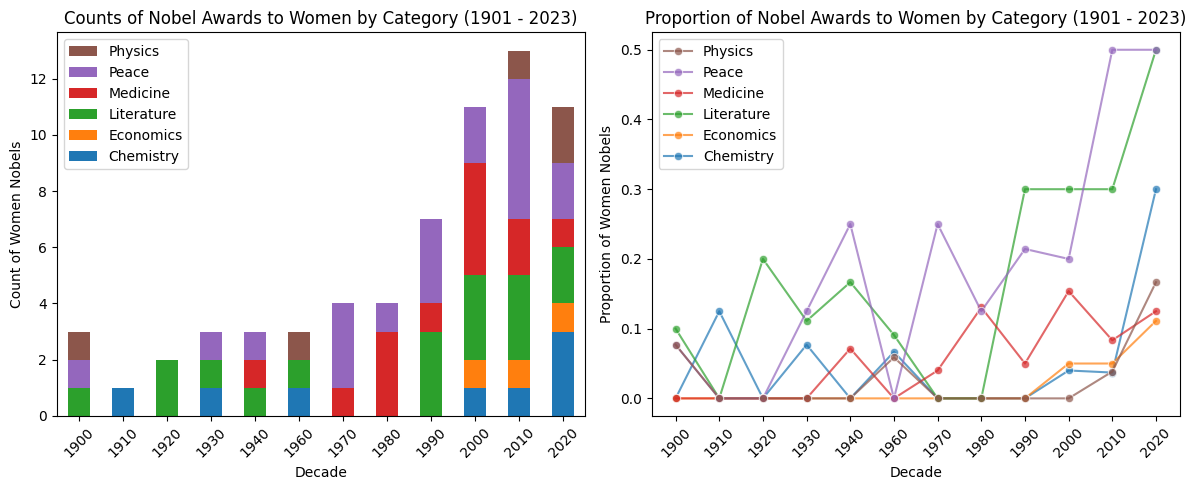

In [24]:
fig3, ax3 = plt.subplots(1, 2, figsize=(12, 5))

df_left_plot = df_fem_cat.iloc[:, :-1]
# rename columns so index is clearer
df_left_plot = df_left_plot.rename(
    columns ={'Chemistry_women': 'Chemistry',
              'Economics_women': 'Economics',
              'Literature_women': 'Literature', 'Medicine_women': 'Medicine',
              'Peace_women': 'Peace', 'Physics_women': 'Physics'
             })

ax3[0] = df_left_plot.plot(kind='bar', stacked=True,
                           title="Counts of Nobel Awards to Women by Category (1901 - 2023)",
                           xlabel="Decade", ylabel="Count of Women Nobels", ax=ax3[0])
ax3[0].tick_params(axis='x', labelrotation=45)
# change order of legend to match the bar order - Get the handles and labels
handles, labels = ax3[0].get_legend_handles_labels()
ax3[0].legend(reversed(handles), reversed(labels), title='')
# line plot of proportions by decade and cat
sns.lineplot(x=df_right_long.index, y='women_prop', data=df_right_long, hue='Category',
             alpha=0.7, marker='o', ax=ax3[1])
# clean up line plot: reverse category order
handles, labels = ax3[1].get_legend_handles_labels()
ax3[1].legend(reversed(handles), reversed(labels), title='')
# revise axis labels, add title, rotate xtick vals, add
ax3[1].set_xlabel("Decade")
ax3[1].set_ylabel("Proportion of Women Nobels")
ax3[1].set_title("Proportion of Nobel Awards to Women by Category (1901 - 2023)")
ax3[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

In [25]:
# Create dataframe with count of female winners in each category for each decade
df_sex_cat = df_nobel.loc[:, ["year", "sex", "category"]]
# create decade column
df_sex_cat['decade'] = df_sex_cat["year"].astype(str).str[:3] + "0"
df_sex_cat['value'] = 1
# filter for women
df_fem_cat = df_sex_cat.loc[df_sex_cat['sex'] == "Female", ["decade", "category", "value"]]
df_fem_cat.head(10)


,decade,category,value
19,1900,Physics,1
29,1900,Peace,1
51,1900,Literature,1
62,1910,Chemistry,1
128,1920,Literature,1
141,1920,Literature,1
160,1930,Peace,1
179,1930,Chemistry,1
198,1930,Literature,1
218,1940,Literature,1


In [26]:
# aggegate to get counts per decade and category, but groupby creates a series with a multi-index
fem_cat_decades = df_fem_cat.groupby(["decade", "category"])["value"].sum()
dec_cat = fem_cat_decades.index.to_list()
dec_cat[0:10]

[('1900', 'Literature'),
 ('1900', 'Peace'),
 ('1900', 'Physics'),
 ('1910', 'Chemistry'),
 ('1920', 'Literature'),
 ('1930', 'Chemistry'),
 ('1930', 'Literature'),
 ('1930', 'Peace'),
 ('1940', 'Literature'),
 ('1940', 'Medicine')]

In [27]:
# break the multi-index apart so we can create a dataframe which can be joined
decades = [dec_cat[i][0] for i in range(len(dec_cat))]
categories = [dec_cat[i][1] for i in range(len(dec_cat))]
df_fem_cat_decs = pd.DataFrame({"decade": decades, "category": categories, "count_women": fem_cat_decades.values})
print(df_fem_cat_decs.shape)
df_fem_cat_decs.head()

(38, 3)


,decade,category,count_women
0,1900,Literature,1
1,1900,Peace,1
2,1900,Physics,1
3,1910,Chemistry,1
4,1920,Literature,2


In [28]:
df_all_cat = df_nobel.loc[:, ["year", "category"]]
# create decade column
df_all_cat['decade'] = df_all_cat["year"].astype(str).str[:3] + "0"
df_all_cat['value'] = 1
df_all_cat.head()
all_cat_decades = df_all_cat.groupby(["decade", "category"])["value"].sum()
all_cat_decades.head()

decade  category  
1900    Chemistry      9
        Literature    10
        Medicine      11
        Peace         14
        Physics       13
Name: value, dtype: int64

In [29]:
dec_cat_all = all_cat_decades.index.to_list()
# dec_cat_all[0:10]

# break the multi-index apart so we can create a dataframe which can be joined
decades_all = [dec_cat_all[i][0] for i in range(len(dec_cat_all))]
categories_all = [dec_cat_all[i][1] for i in range(len(dec_cat_all))]
# print(len(decades_all), len(categories_all), len(all_cat_decades.values))
df_all_cat_decs = pd.DataFrame({"decade": decades_all, "category": categories_all, "count_all": all_cat_decades.values})
# print(df_all_cat_decs.shape)
df_all_cat_decs.head()

,decade,category,count_all
0,1900,Chemistry,9
1,1900,Literature,10
2,1900,Medicine,11
3,1900,Peace,14
4,1900,Physics,13


In [30]:
# Join the female and all winner dataframes together
df_female_all = pd.merge(df_fem_cat_decs, df_all_cat_decs, how="left", on=["decade", "category"])
df_female_all["prop_female"] = df_female_all["count_women"] / df_female_all["count_all"]
df_female_all.tail()

,decade,category,count_women,count_all,prop_female
33,2020,Economics,1,9,0.111111
34,2020,Literature,2,4,0.500000
35,2020,Medicine,1,8,0.125000
36,2020,Peace,2,7,0.285714
37,2020,Physics,2,12,0.166667


In [31]:
df_female_all.sort_values(by="prop_female", ascending=False, inplace=True)
# print(df_female_all.shape)
df_female_all.head()  # 2020, 0.5 in Literature

,decade,category,count_women,count_all,prop_female
34,2020,Literature,2,4,0.500000
30,2010,Peace,5,14,0.357143
23,2000,Literature,3,10,0.300000
18,1990,Literature,3,10,0.300000
32,2020,Chemistry,3,10,0.300000


In [32]:
df_max_female = df_female_all.iloc[:1, :]
max_female_decade = int(df_max_female.iloc[:1, 0].values[0])
max_female_category = df_max_female.iloc[:1, 1].values[0]
max_female_prop = df_max_female.iloc[:1, 4].values[0]
print(f"Decade with the highest proportion of female laureates was {max_female_decade} \
in the category of {max_female_category} at {round(max_female_prop * 100)}%")
max_female_dict = {max_female_decade : max_female_category}  # NOTE the data only includes the first 4 years of the 2020 decade: 2020-2023

Decade with the highest proportion of female laureates was 2020 in the category of Literature at 50%


## Who was the first woman to receive a Nobel Prize, and in what category?

In [33]:
df_fem_year_cat_name = df_nobel.loc[df_sex_cat['sex'] == 'Female']
df_fem_sorted = df_fem_year_cat_name.loc[:, ['year', 'category', 'full_name']].sort_values("year")
df_fem_sorted.head()

,year,category,full_name
19,1903,Physics,"Marie Curie, née Sklodowska"
29,1905,Peace,"Baroness Bertha Sophie Felicita von Suttner, n..."
51,1909,Literature,Selma Ottilia Lovisa Lagerlöf
62,1911,Chemistry,"Marie Curie, née Sklodowska"
128,1926,Literature,Grazia Deledda


In [34]:
df_first_woman = df_fem_sorted.iloc[:1, :]
df_first_woman
first_woman_name = df_first_woman['full_name'].values[0]
first_woman_category = df_first_woman['category'].values[0]
print(f"The first women to win a Nobel prize was {first_woman_name} in {first_woman_category}")

The first women to win a Nobel prize was Marie Curie, née Sklodowska in Physics


## Which individuals or organizations have won more than one Nobel Prize throughout the years?

<s>Next couple of cells shows that there are far more organization repeats than individuals (which makes sense intuitively) and that **University of California** has won the most Nobel's.</s>

Just need to look at the `full_name` column (originally through I needed to look at `organization_name`, but this is not the case).

In [35]:
df_names_orgs = df_nobel.loc[:, ['full_name', 'organization_name']]
name_counts = df_names_orgs.value_counts(subset='full_name', ascending=False)
print(name_counts.shape[0])  # 993 org's before removing singletons
names_more_than_once = name_counts.loc[lambda x: x > 1]
print(names_more_than_once.shape[0])
print(type(names_more_than_once))
names_list = names_more_than_once.index.to_list()
names_list[:10]

993
6
<class 'pandas.core.series.Series'>


['Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'John Bardeen',
 'Frederick Sanger',
 'Linus Carl Pauling',
 'Marie Curie, née Sklodowska',
 'Office of the United Nations High Commissioner for Refugees (UNHCR)']

In [36]:
# org_counts = df_names_orgs.value_counts(subset='organization_name', ascending=False)
# print(org_counts.shape[0])  # 325 before filtering out singletons
# orgs_more_than_once = org_counts.loc[lambda x: x > 1]
# print(orgs_more_than_once.shape[0])  # 102 after filtering out singletons
# orgs_list = orgs_more_than_once.index.to_list()
# orgs_list[:10]

In [37]:
repeat_set = set(names_list)  # remove duplicates
repeat_list = list(repeat_set)
print(len(repeat_list))
repeat_list

6


['Office of the United Nations High Commissioner for Refugees (UNHCR)',
 'Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'Frederick Sanger',
 'Linus Carl Pauling',
 'John Bardeen',
 'Marie Curie, née Sklodowska']

## Age of Nobel laureates

Nobel prizes are awarded on Decemeber 10 which is the [anniversary of Alfred Nobel’s death](https://www.nobelprize.org/nobel-prize-award-ceremonies/). This allows us to calculate the exact age of each recipient at the time they recieved their prize. Before extending this analysis to include date processing, we need to deal with missing or improperly formatted date values such as `birth_date` and `death_date`.

### Missing and problematic birth dates

Two individuals with missing birthdates in this dataset were: ***Saul Perlmutter***, whose [birthday is 1959-09-22](https://en.wikipedia.org/wiki/Saul_Perlmutter), and ***Venkatraman Ramakrishnan*** whose [birthday is 1952-04-05](https://cmeindia.in/history-today-in-medicine-dr-venkataraman-ramakrishnan/). [The birthday of laureate ***Nadia Murad*** is 1993-03-03](en.wikipedia.org/wiki/Nadia_Murad) but was listed as `1993-00-00` in the data. We'll fix these values in this section, but that still leaves two questions:

+ How do we handle laureates with missing `death_date` values because they are still alive?
  - We'll leave the values as missing and use as an indicator that the laureate is still alive.
+ How doe we handle organizations with missing `death_date` and `birth_date`?
  - We'll remove the organizations is this part of the analysis.

References:

1. Nobel Prize Award Ceremonies:  
   https://www.nobelprize.org/nobel-prize-award-ceremonies/
2. The sex gap in life expectancy has changed over time:  
   https://ourworldindata.org/data-insights/the-sex-gap-in-life-expectancy-has-changed-over-time
3. Saul Perlmutter: https://en.wikipedia.org/wiki/Saul_Perlmutter
4. Venkatraman Ramakrishnan: https://en.wikipedia.org/wiki/Venki_Ramakrishnan  
   Exact birth date: https://cmeindia.in/history-today-in-medicine-dr-venkataraman-ramakrishnan/
5. Nadia Murad: en.wikipedia.org/wiki/Nadia_Murad
6. Paul M. Romer: https://en.wikipedia.org/wiki/Paul_Romer
7. Michael Houghton: https://en.wikipedia.org/wiki/Michael_Houghton
   - No reference of his exact birthdate, so imputed with middle of the year 1949-07-01
8. Ardem Patapoutian: https://en.wikipedia.org/wiki/Ardem_Patapoutian

In [38]:
from datetime import datetime, timedelta

# any missing birth dates?
missing_birth_dates = df_nobel['birth_date'].isnull()
df_missing_bdate = df_nobel[missing_birth_dates]
df_missing_bd_org = df_missing_bdate.loc[df_missing_bdate['laureate_type'] == 'Organization']
df_missing_bd_ind = df_missing_bdate.loc[df_missing_bdate['laureate_type'] == 'Individual']
print(f"number of rows with missing birth dates that are organizations: {df_missing_bd_org.shape[0]}")
print(f"  number of rows with missing birth dates that are individuals:  {df_missing_bd_ind.shape[0]}")
print(f"                 total number of rows with missing birth dates: {df_missing_bdate.shape[0]}")
relevant_cols = ['year', 'category', 'laureate_type', 'full_name', 'sex', 'birth_date', 'death_date']
df_missing_bdate[relevant_cols]

number of rows with missing birth dates that are organizations: 30
  number of rows with missing birth dates that are individuals:  2
                 total number of rows with missing birth dates: 32


,year,category,laureate_type,full_name,sex,birth_date,death_date
24,1904,Peace,Organization,Institut de droit international (Institute of ...,NaN,NaN,NaT
60,1910,Peace,Organization,Bureau international permanent de la Paix (Per...,NaN,NaN,NaT
89,1917,Peace,Organization,Comité international de la Croix Rouge (Intern...,NaN,NaN,NaT
200,1938,Peace,Organization,Office international Nansen pour les Réfugiés ...,NaN,NaN,NaT
215,1944,Peace,Organization,Comité international de la Croix Rouge (Intern...,NaN,NaN,NaT
237,1947,Peace,Organization,Friends Service Council (The Quakers),NaN,NaN,NaT
238,1947,Peace,Organization,American Friends Service Committee (The Quakers),NaN,NaN,NaT
283,1954,Peace,Organization,Office of the United Nations High Commissioner...,NaN,NaN,NaT
348,1963,Peace,Organization,Comité international de la Croix Rouge (Intern...,NaN,NaN,NaT
349,1963,Peace,Organization,Ligue des Sociétés de la Croix-Rouge (League o...,NaN,NaN,NaT


In [39]:
# remove the organization laureate_type
df_no_orgs = df_nobel.loc[df_nobel['laureate_type'].isin(['Individual']), :]
df_no_orgs['birth_date'].isnull().sum()
# where are the missing individual birth dates?
df_no_orgs.loc[df_no_orgs['birth_date'].isnull(), relevant_cols]

,year,category,laureate_type,full_name,sex,birth_date,death_date
816,2009,Chemistry,Individual,Venkatraman Ramakrishnan,Male,NaN,NaT
850,2011,Physics,Individual,Saul Perlmutter,Male,NaN,NaT


In [40]:
# fix the two missing birth dates - values found on wikipedia
df_nobel.loc[df_nobel['full_name'] == 'Saul Perlmutter', 'birth_date'] = '1959-09-22'
df_nobel.loc[df_nobel['full_name'] == 'Venkatraman Ramakrishnan', 'birth_date'] = '1952-04-05'
# rebuild df_no_orgs with fixed birth dates
df_no_orgs = df_nobel.loc[df_nobel['laureate_type'].isin(['Individual']), :]

In [41]:
# try to convert birth date strings to datetimes
# df_no_orgs['birth_date'] = pd.to_datetime(df_no_orgs['birth_date'], format="%Y-%m-%d")
# previous command generates: ValueError: time data "1993-00-00" doesn't match format "%Y-%m-%d", at position 901.
df_no_orgs = df_no_orgs.reset_index()  # reset index so position and index align to make it easier to see problem records
# find all birth dates that end with 00-00 - learned to look for this the hard way :-)
df_only_bd_year = df_no_orgs.loc[df_no_orgs['birth_date'].str.endswith("00-00"), relevant_cols]
print(df_only_bd_year.shape)  # (12, 7) so 12 problematic dates

(12, 7)


In [42]:
df_only_bd_year.to_csv("./df_only_bd_year.csv", index_label='index')  # export ind's with only year for birth date
df_only_bd_year

,year,category,laureate_type,full_name,sex,birth_date,death_date
901,2018,Peace,Individual,Nadia Murad,Female,1993-00-00,NaT
903,2018,Economics,Individual,Paul M. Romer,Male,1955-00-00,NaT
920,2020,Medicine,Individual,Michael Houghton,Male,1949-00-00,NaT
931,2021,Medicine,Individual,Ardem Patapoutian,Male,1967-00-00,NaT
937,2021,Literature,Individual,Abdulrazak Gurnah,Male,1948-00-00,NaT
939,2021,Peace,Individual,Dmitry Muratov,Male,1961-00-00,NaT
940,2021,Economics,Individual,David Card,Male,1956-00-00,NaT
949,2022,Chemistry,Individual,Morten Meldal,Male,1954-00-00,NaT
960,2023,Chemistry,Individual,Moungi Bawendi,Male,1961-00-00,NaT
961,2023,Chemistry,Individual,Louis Brus,Male,1943-00-00,NaT


In [43]:
indices_to_fix = df_only_bd_year.index.tolist()
print(indices_to_fix)
#           Murad         Romer         Houghton      Patapoutian
bd_fixes = ["1993-03-03", "1955-11-06", "1949-07-01", "1967-10-01", "", "", "", "", "", "", "", ""]

[901, 903, 920, 931, 937, 939, 940, 949, 960, 961, 962, 965]


In [44]:
# remove the organization laureate_type
df_no_orgs = df_nobel.loc[df_nobel['laureate_type'].isin(['Individual']), :]
df_no_orgs['birth_date'].isnull().sum()
# df_no_orgs.shape  # (966, 19)
# find incomplete birth dates

# df_no_orgs.loc[df_no_orgs['birth_date'].str.endswith("00-00"), relevant_cols]

np.int64(0)

In [45]:
# fix problem birth dates
# df_nobel.loc[df_nobel['full_name'] == 'Saul Perlmutter', 'birth_date'] = '1959-09-22'
# df_nobel.loc[df_nobel['full_name'] == 'Venkatraman Ramakrishnan', 'birth_date'] = '1952-04-05'
# df_nobel.loc[df_nobel['full_name'] == 'Nadia Murad', 'birth_date'] = '1993-03-03'
# df_nobel.loc[df_nobel['full_name'] == 'Paul M. Romer', 'birth_date'] = '1955-11-06'
# df_nobel.loc[df_nobel['full_name'] == 'Michael Houghton', 'birth_date'] = '1949-07-01'  # impute with middle of the year
# df_nobel.loc[df_nobel['full_name'] == 'Ardem Patapoutian', 'birth_date'] = '1967-10-01'
# df_nobel.loc[df_nobel['full_name'] == '', 'birth_date'] = ''



# convert the birth date col to datetime
# df_no_orgs['birth_date'] = pd.to_datetime(df_no_orgs['birth_date'], format="%Y-%m-%d")
# df_no_orgs.info()

In [46]:

#
# df_no_orgs['birth_date'] = pd.to_datetime(df_no_orgs['birth_date'], format="%Y-%m-%d")
# find the problem records id'd when calling to to_datetime
# df_no_orgs.loc[df_no_orgs['birth_date'] == '1993-00-00', relevant_cols]  # Nadia Murad
# df_no_orgs.loc[df_no_orgs['birth_date'] == '1955-00-00', relevant_cols]  # Paul M. Romer
# df_no_orgs.loc[df_no_orgs['birth_date'] == '1949-00-00', relevant_cols]  # Michael Houghton
# df_no_orgs.loc[df_no_orgs['birth_date'] == '1967-00-00', relevant_cols]  # Ardem Patapoutian
# df_no_orgs.info()